# 01. Introduction

**Project:** Gym Customer Churn Prediction

Notebook baseline trước đó đã xây dựng workflow modeling chuẩn và so sánh nhiều mô hình trên dữ liệu gốc. Trong nhiều bài toán churn, baseline có thể đã đạt performance khá cao vì các biến hành vi như tần suất đi tập, lifetime và trạng thái hợp đồng có tín hiệu mạnh.

Notebook này kiểm tra liệu **feature engineering dựa trên insight từ EDA và baseline** có giúp cải thiện performance hay không. Các feature mới tập trung vào các nhóm ý nghĩa business:

- **Engagement:** mức độ đi tập và sự sụt giảm hoạt động.
- **Loyalty / commitment:** thời gian gắn bó và độ cam kết hợp đồng.
- **Contract renewal risk:** rủi ro khi hợp đồng sắp hết hạn.
- **Convenience / social factors:** vị trí, partner, promo, group visits và thông tin liên hệ.

Notebook này **không dùng SMOTE**, **không tuning hyperparameter phức tạp**, **không tạo feature từ target `Churn`**, và luôn thực hiện train-test split trước khi fit scaler/model để tránh data leakage.


# 02. Import Libraries

Import thư viện cho data handling, visualization, pipeline modeling, metrics, cross validation và lưu artifact.


In [18]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("xgboost is not installed. XGBoost will be skipped.")

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("lightgbm is not installed. LightGBM will be skipped.")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("catboost is not installed. CatBoost will be skipped.")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "Churn"

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# 03. Load Dataset

Load dataset gốc, kiểm tra shape, vài dòng đầu, danh sách cột và phân phối target.


Project: Gym Customer Churn Prediction
Project root: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn
Data path: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv
Dataset shape: 4,000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


Columns:
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']


,count,percentage
Churn,,
0,2939,73.4700
1,1061,26.5200


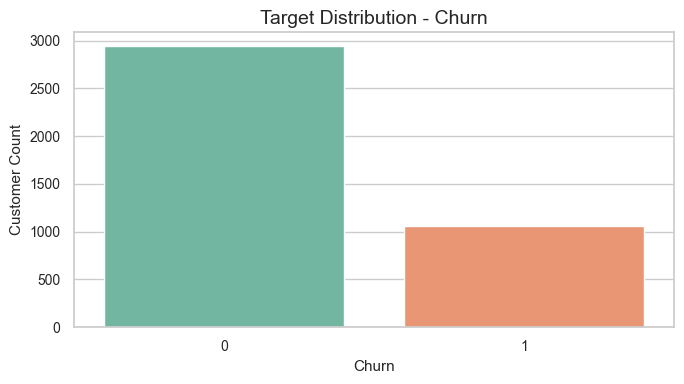

In [19]:
PROJECT_NAME = "Gym Customer Churn Prediction"
DATA_PATH_CANDIDATES = [
    Path(r"D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv"),
    Path.cwd() / "Data" / "gym_churn_us.csv",
    Path.cwd().parent / "Data" / "gym_churn_us.csv",
]

DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Tried: {[str(path) for path in DATA_PATH_CANDIDATES]}")

PROJECT_ROOT = DATA_PATH.parent.parent
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Project: {PROJECT_NAME}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())
print("Columns:")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found.")

target_distribution = pd.DataFrame({
    "count": df[TARGET_COL].value_counts().sort_index(),
    "percentage": (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(target_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COL, palette="Set2")
plt.title("Target Distribution - Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# 04. Define Original Features

Define feature gốc và target. Notebook này giữ nguyên dữ liệu gốc, không chỉnh sửa trực tiếp dataframe ban đầu.


In [20]:
ORIGINAL_FEATURES = [
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Contract_period",
    "Group_visits",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]

missing_features = [col for col in ORIGINAL_FEATURES if col not in df.columns]
if missing_features:
    print(f"Warning: missing original features will be skipped: {missing_features}")

original_features = [col for col in ORIGINAL_FEATURES if col in df.columns]

X_original = df[original_features].copy()
y = df[TARGET_COL].copy()

print(f"Original feature count: {len(original_features)}")
print(original_features)
print(f"X_original shape: {X_original.shape}")
print(f"y shape: {y.shape}")


Original feature count: 13
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
X_original shape: (4000, 13)
y shape: (4000,)


# 05. Train-Test Split

Dùng cùng strategy như baseline: test size 20%, stratify theo target và random state cố định. Split được thực hiện trước feature engineering thresholds và trước khi fit scaler/model để tránh leakage.


In [21]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train_original: {X_train_original.shape}")
print(f"X_test_original: {X_test_original.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

train_dist = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
})
test_dist = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})

print("Train target distribution:")
display(train_dist)
print("Test target distribution:")
display(test_dist)


X_train_original: (3200, 13)
X_test_original: (800, 13)
y_train: (3200,)
y_test: (800,)
Train target distribution:


,count,percentage
Churn,,
0,2351,73.4700
1,849,26.5300


Test target distribution:


,count,percentage
Churn,,
0,588,73.5000
1,212,26.5000


# 06. Feature Engineering Function

Feature engineering chỉ dùng các cột input, không dùng target `Churn`. Function nhận `X`, copy dữ liệu để không sửa data gốc, xử lý division by zero bằng epsilon, và cuối cùng replace infinite values rồi fill missing bằng 0.

Riêng feature `high_spending` và `low_spending` cần percentile threshold. Để tránh leakage, thresholds được fit trên `X_train_original` rồi truyền vào function khi transform train/test. Trong production, threshold cũng cần được lưu cùng pipeline.


In [22]:
def get_col(data: pd.DataFrame, column: str, default=0):
    """Safely return a column or a default-valued Series if missing."""
    if column in data.columns:
        return data[column]
    return pd.Series(default, index=data.index)


def create_features(data: pd.DataFrame, thresholds: dict | None = None) -> pd.DataFrame:
    """Create engineered features from input X only. This function never uses target."""
    df_fe = data.copy()
    eps = 1e-6

    lifetime = get_col(df_fe, "Lifetime")
    freq_total = get_col(df_fe, "Avg_class_frequency_total")
    freq_current = get_col(df_fe, "Avg_class_frequency_current_month")
    contract_period = get_col(df_fe, "Contract_period")
    month_to_end = get_col(df_fe, "Month_to_end_contract")
    additional_charges = get_col(df_fe, "Avg_additional_charges_total")
    near_location = get_col(df_fe, "Near_Location")
    partner = get_col(df_fe, "Partner")
    promo_friends = get_col(df_fe, "Promo_friends")
    phone = get_col(df_fe, "Phone")
    group_visits = get_col(df_fe, "Group_visits")

    # A. Engagement features
    df_fe["frequency_drop"] = freq_total - freq_current
    df_fe["frequency_ratio_current_total"] = freq_current / (freq_total + eps)
    df_fe["low_current_activity"] = (freq_current < 1).astype(int)
    df_fe["high_current_activity"] = (freq_current >= 3).astype(int)
    df_fe["engagement_score"] = lifetime * freq_current
    df_fe["total_engagement_score"] = lifetime * freq_total

    # B. Contract / renewal risk features
    df_fe["contract_remaining_ratio"] = month_to_end / (contract_period + eps)
    df_fe["is_contract_ending"] = (month_to_end <= 1).astype(int)
    df_fe["is_short_contract"] = (contract_period <= 1).astype(int)
    df_fe["is_long_contract"] = (contract_period >= 12).astype(int)
    df_fe["renewal_pressure_score"] = df_fe["is_contract_ending"] * df_fe["is_short_contract"]

    # C. Loyalty features
    df_fe["is_new_customer"] = (lifetime <= 1).astype(int)
    df_fe["is_loyal_customer"] = (lifetime >= 6).astype(int)
    df_fe["lifetime_per_contract"] = lifetime / (contract_period + eps)
    df_fe["loyalty_score"] = lifetime * contract_period

    # D. Spending features
    df_fe["spending_per_month"] = additional_charges / (lifetime + 1)
    if thresholds is None:
        spending_q25 = additional_charges.quantile(0.25)
        spending_q75 = additional_charges.quantile(0.75)
    else:
        spending_q25 = thresholds.get("spending_q25", additional_charges.quantile(0.25))
        spending_q75 = thresholds.get("spending_q75", additional_charges.quantile(0.75))
    df_fe["high_spending"] = (additional_charges >= spending_q75).astype(int)
    df_fe["low_spending"] = (additional_charges <= spending_q25).astype(int)

    # E. Convenience / social features
    df_fe["convenience_score"] = near_location + partner + promo_friends + phone
    df_fe["social_commitment_score"] = group_visits + promo_friends + partner
    df_fe["far_no_group"] = ((near_location == 0) & (group_visits == 0)).astype(int)
    df_fe["no_contact_info"] = (phone == 0).astype(int)

    # F. Interaction features
    df_fe["new_low_activity"] = df_fe["is_new_customer"] * df_fe["low_current_activity"]
    df_fe["ending_low_activity"] = df_fe["is_contract_ending"] * df_fe["low_current_activity"]
    df_fe["far_low_activity"] = (1 - near_location) * df_fe["low_current_activity"]
    df_fe["short_contract_low_activity"] = df_fe["is_short_contract"] * df_fe["low_current_activity"]
    df_fe["no_group_low_activity"] = (1 - group_visits) * df_fe["low_current_activity"]
    df_fe["partner_long_contract"] = partner * df_fe["is_long_contract"]
    df_fe["promo_group"] = promo_friends * group_visits

    # G. Optional log features
    df_fe["log_lifetime"] = np.log1p(lifetime.clip(lower=0))
    df_fe["log_additional_charges"] = np.log1p(additional_charges.clip(lower=0))
    df_fe["log_frequency_current"] = np.log1p(freq_current.clip(lower=0))
    df_fe["log_frequency_total"] = np.log1p(freq_total.clip(lower=0))

    df_fe = df_fe.replace([np.inf, -np.inf], np.nan).fillna(0)
    return df_fe


# 07. Apply Feature Engineering

Fit spending thresholds trên train set, sau đó transform train và test bằng cùng thresholds. Cách này giúp so sánh công bằng và tránh leakage từ test set.


In [23]:
feature_thresholds = {
    "spending_q25": X_train_original["Avg_additional_charges_total"].quantile(0.25) if "Avg_additional_charges_total" in X_train_original.columns else 0,
    "spending_q75": X_train_original["Avg_additional_charges_total"].quantile(0.75) if "Avg_additional_charges_total" in X_train_original.columns else 0,
}

X_train_fe = create_features(X_train_original, thresholds=feature_thresholds)
X_test_fe = create_features(X_test_original, thresholds=feature_thresholds)

new_features = [col for col in X_train_fe.columns if col not in X_train_original.columns]

print("Original train shape:", X_train_original.shape)
print("Feature engineered train shape:", X_train_fe.shape)
print("Original test shape:", X_test_original.shape)
print("Feature engineered test shape:", X_test_fe.shape)
print(f"Number of new features: {len(new_features)}")
print("New features:")
print(new_features)

quality_check = pd.DataFrame({
    "dataset": ["X_train_fe", "X_test_fe"],
    "missing_values": [int(X_train_fe.isna().sum().sum()), int(X_test_fe.isna().sum().sum())],
    "infinite_values": [int(np.isinf(X_train_fe.to_numpy()).sum()), int(np.isinf(X_test_fe.to_numpy()).sum())],
})
display(quality_check)


Original train shape: (3200, 13)
Feature engineered train shape: (3200, 46)
Original test shape: (800, 13)
Feature engineered test shape: (800, 46)
Number of new features: 33
New features:
['frequency_drop', 'frequency_ratio_current_total', 'low_current_activity', 'high_current_activity', 'engagement_score', 'total_engagement_score', 'contract_remaining_ratio', 'is_contract_ending', 'is_short_contract', 'is_long_contract', 'renewal_pressure_score', 'is_new_customer', 'is_loyal_customer', 'lifetime_per_contract', 'loyalty_score', 'spending_per_month', 'high_spending', 'low_spending', 'convenience_score', 'social_commitment_score', 'far_no_group', 'no_contact_info', 'new_low_activity', 'ending_low_activity', 'far_low_activity', 'short_contract_low_activity', 'no_group_low_activity', 'partner_long_contract', 'promo_group', 'log_lifetime', 'log_additional_charges', 'log_frequency_current', 'log_frequency_total']


,dataset,missing_values,infinite_values
0,X_train_fe,0,0
1,X_test_fe,0,0


# 08. Analyze New Features Quickly

Phân tích nhanh engineered features trên **training set only** để tránh nhìn test quá nhiều. Ta tính correlation giữa feature mới và target `Churn` trên train set, sau đó xem top 15 theo absolute correlation.


,feature,correlation_with_churn,abs_correlation
0,frequency_drop,0.5945,0.5945
29,log_lifetime,-0.5759,0.5759
11,is_new_customer,0.5512,0.5512
22,new_low_activity,0.4609,0.4609
25,short_contract_low_activity,0.4476,0.4476
23,ending_low_activity,0.4476,0.4476
31,log_frequency_current,-0.4154,0.4154
4,engagement_score,-0.4092,0.4092
7,is_contract_ending,0.3923,0.3923
10,renewal_pressure_score,0.3923,0.3923


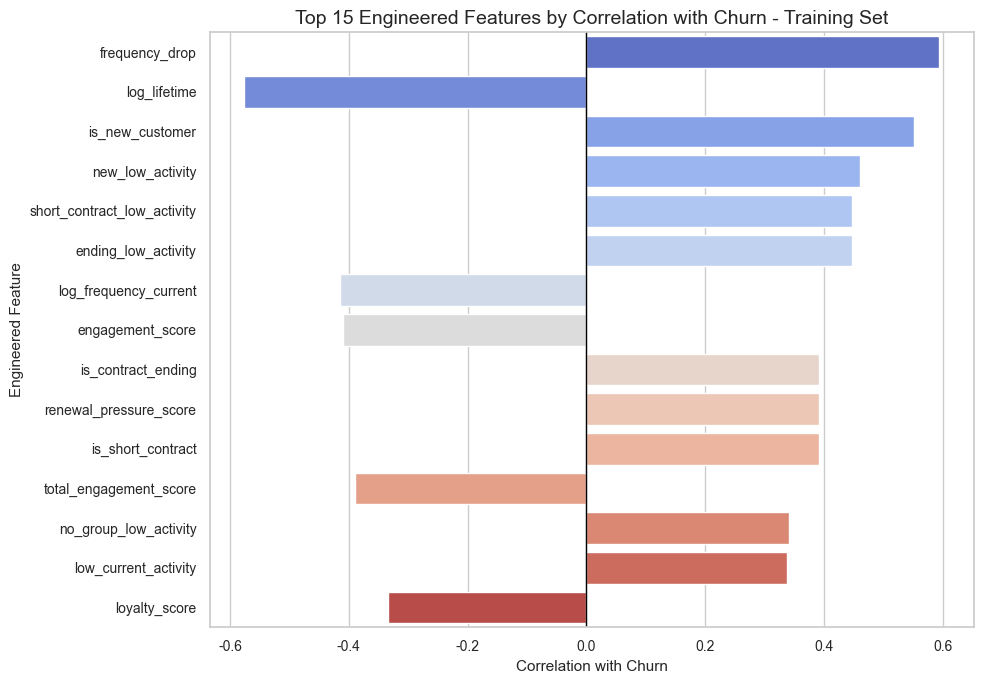

In [24]:
train_fe_with_target = X_train_fe.copy()
train_fe_with_target[TARGET_COL] = y_train.values

new_feature_corr = []
for feature in new_features:
    if train_fe_with_target[feature].nunique() > 1:
        corr_value = train_fe_with_target[[feature, TARGET_COL]].corr().iloc[0, 1]
    else:
        corr_value = 0
    new_feature_corr.append({
        "feature": feature,
        "correlation_with_churn": corr_value,
        "abs_correlation": abs(corr_value),
    })

new_feature_corr_df = pd.DataFrame(new_feature_corr).sort_values("abs_correlation", ascending=False)
top15_new_corr = new_feature_corr_df.head(15)
display(top15_new_corr)

plt.figure(figsize=(10, 7))
sns.barplot(data=top15_new_corr, y="feature", x="correlation_with_churn", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 Engineered Features by Correlation with Churn - Training Set")
plt.xlabel("Correlation with Churn")
plt.ylabel("Engineered Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_top15_engineered_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


# 09. Define Models

Dùng các model mạnh từ baseline để tiết kiệm thời gian và tập trung vào câu hỏi chính: feature engineering có giúp cải thiện performance không?


In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

if CatBoostClassifier is not None:
    models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)

print(f"Models to train: {len(models)}")
print(list(models.keys()))


Models to train: 7
['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']


# 10. Evaluation Function

Tạo function train/evaluate dùng chung cho original features và feature engineered dataset. Logistic Regression dùng StandardScaler; tree-based models dùng passthrough để giữ workflow tự nhiên cho cây quyết định.


In [26]:
def model_needs_scaling(model_name: str) -> bool:
    return model_name == "Logistic Regression"


def build_pipeline(model_name: str, model, feature_names: list[str]) -> Pipeline:
    if model_needs_scaling(model_name):
        preprocessor = ColumnTransformer(
            transformers=[("numeric", StandardScaler(), feature_names)],
            remainder="drop",
        )
    else:
        preprocessor = "passthrough"

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def get_positive_scores(pipeline: Pipeline, X_data: pd.DataFrame):
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X_data)[:, 1]
    if hasattr(pipeline, "decision_function"):
        return pipeline.decision_function(X_data)
    return None


def train_evaluate_models(X_train, X_test, y_train, y_test, models: dict, experiment_name: str):
    """Train and evaluate multiple models for one experiment."""
    results = []
    trained_models = {}
    feature_names = X_train.columns.tolist()

    for model_name, model in models.items():
        print(f"[{experiment_name}] Training {model_name}...")
        try:
            pipeline = build_pipeline(model_name, model, feature_names)
            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)
            y_score = get_positive_scores(pipeline, X_test)

            results.append({
                "Experiment": experiment_name,
                "Model": model_name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0),
                "ROC_AUC": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
            })
            trained_models[model_name] = pipeline
        except Exception as exc:
            print(f"Warning: {model_name} failed in {experiment_name}. Error: {exc}")

    results_df = pd.DataFrame(results).sort_values(["ROC_AUC", "F1"], ascending=False).reset_index(drop=True)
    return results_df, trained_models


# 11. Train Models on Original Features

Train cùng bộ model trên original features để tạo mốc so sánh trực tiếp trong notebook này.


In [27]:
results_original, trained_original = train_evaluate_models(
    X_train_original,
    X_test_original,
    y_train,
    y_test,
    models,
    experiment_name="Original",
)

display(results_original.style.highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"], color="#C8E6C9").format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
}))


[Original] Training Logistic Regression...
[Original] Training Random Forest...
[Original] Training Extra Trees...
[Original] Training Gradient Boosting...
[Original] Training XGBoost...
[Original] Training LightGBM...
[Original] Training CatBoost...


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Original,CatBoost,0.9475,0.9167,0.8821,0.8990,0.9826
1,Original,XGBoost,0.9450,0.9078,0.8821,0.8947,0.9800
2,Original,LightGBM,0.9413,0.9024,0.8726,0.8873,0.9782
3,Original,Logistic Regression,0.9250,0.8800,0.8302,0.8544,0.9774
4,Original,Gradient Boosting,0.9437,0.9196,0.8632,0.8905,0.9774
5,Original,Random Forest,0.9263,0.8844,0.8302,0.8564,0.9683
6,Original,Extra Trees,0.9137,0.8667,0.7972,0.8305,0.9579


# 12. Train Models on Feature Engineered Dataset

Train cùng bộ model trên dataset đã có engineered features để kiểm tra feature mới có cải thiện hiệu quả dự đoán hay không.


In [28]:
results_fe, trained_fe = train_evaluate_models(
    X_train_fe,
    X_test_fe,
    y_train,
    y_test,
    models,
    experiment_name="Feature Engineered",
)

display(results_fe.style.highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"], color="#C8E6C9").format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
}))


[Feature Engineered] Training Logistic Regression...
[Feature Engineered] Training Random Forest...
[Feature Engineered] Training Extra Trees...
[Feature Engineered] Training Gradient Boosting...
[Feature Engineered] Training XGBoost...
[Feature Engineered] Training LightGBM...
[Feature Engineered] Training CatBoost...


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Feature Engineered,CatBoost,0.9637,0.9598,0.9009,0.9294,0.9897
1,Feature Engineered,LightGBM,0.9537,0.9310,0.8915,0.9108,0.9895
2,Feature Engineered,XGBoost,0.9563,0.9275,0.9057,0.9165,0.9885
3,Feature Engineered,Gradient Boosting,0.9613,0.9502,0.9009,0.9249,0.9884
4,Feature Engineered,Random Forest,0.9675,0.9604,0.9151,0.9372,0.9884
5,Feature Engineered,Extra Trees,0.9487,0.9171,0.8868,0.9017,0.9824
6,Feature Engineered,Logistic Regression,0.9313,0.8867,0.8491,0.8675,0.9779


# 13. Compare Original vs Feature Engineering

So sánh trực tiếp performance của từng model trước và sau feature engineering. Nếu baseline đã rất cao, improvement nhỏ vẫn có thể hợp lý. Ngược lại, nếu metric giảm, feature engineering có thể tạo noise hoặc làm model overfit hơn.


,Model,Original_ROC_AUC,Original_F1,Original_Recall,FE_ROC_AUC,FE_F1,FE_Recall,Delta_ROC_AUC,Delta_F1,Delta_Recall
0,Extra Trees,0.9579,0.8305,0.7972,0.9824,0.9017,0.8868,+0.0244,+0.0712,+0.0896
1,Random Forest,0.9683,0.8564,0.8302,0.9884,0.9372,0.9151,+0.0200,+0.0808,+0.0849
2,LightGBM,0.9782,0.8873,0.8726,0.9895,0.9108,0.8915,+0.0113,+0.0236,+0.0189
3,Gradient Boosting,0.9774,0.8905,0.8632,0.9884,0.9249,0.9009,+0.0111,+0.0344,+0.0377
4,XGBoost,0.9800,0.8947,0.8821,0.9885,0.9165,0.9057,+0.0085,+0.0217,+0.0236
5,CatBoost,0.9826,0.8990,0.8821,0.9897,0.9294,0.9009,+0.0070,+0.0304,+0.0189
6,Logistic Regression,0.9774,0.8544,0.8302,0.9779,0.8675,0.8491,+0.0004,+0.0131,+0.0189


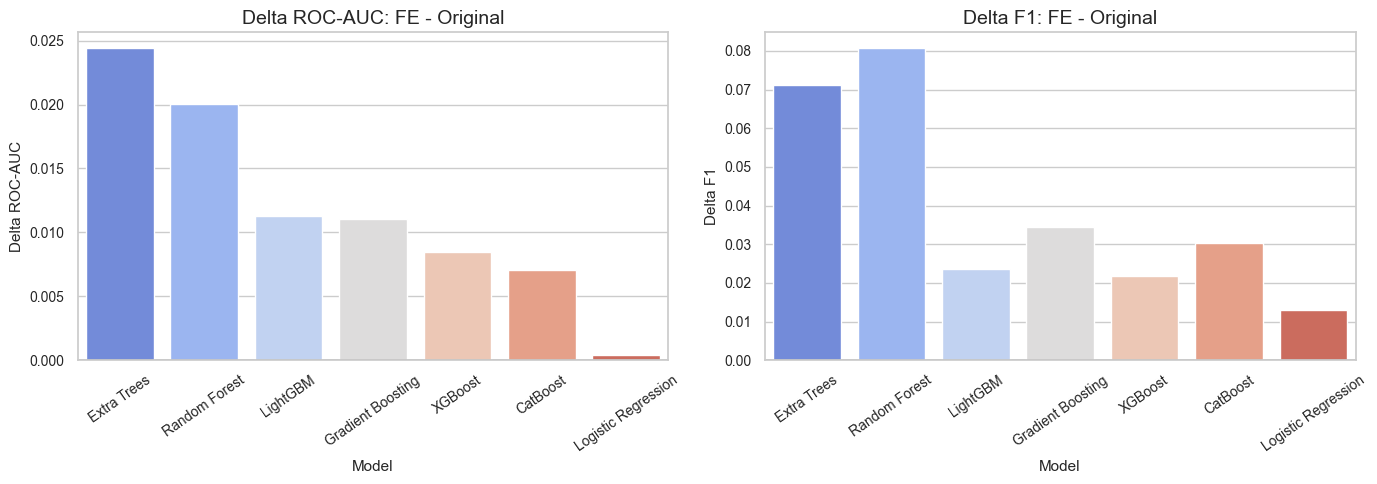

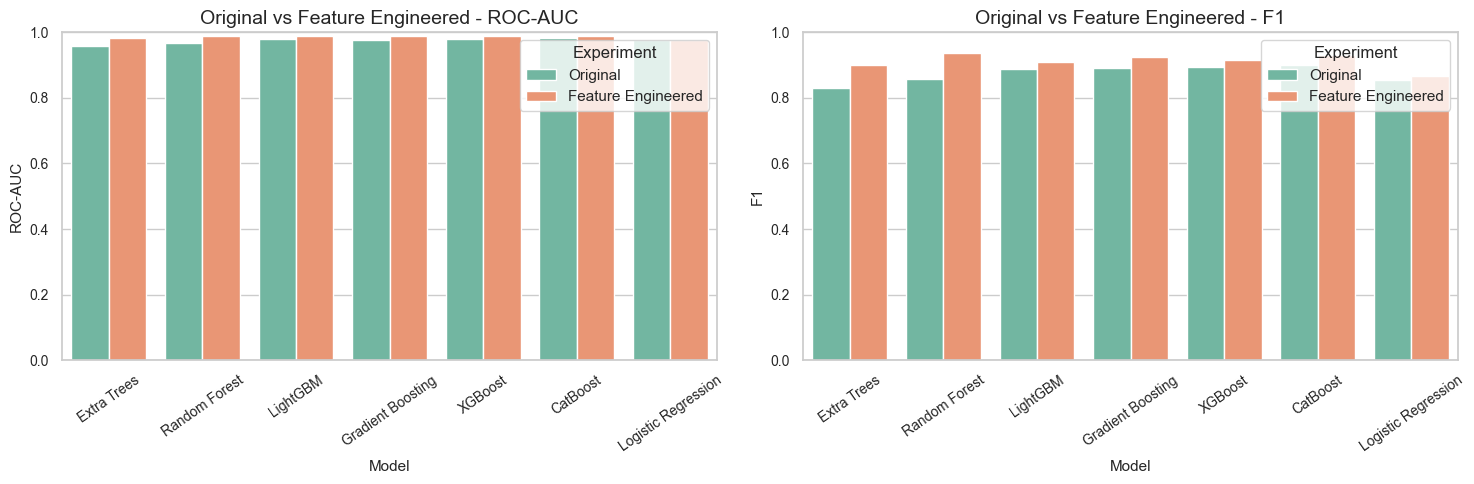

Models improved by ROC-AUC: ['Extra Trees', 'Random Forest', 'LightGBM', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
Models declined by ROC-AUC: None


In [29]:
comparison_df = results_original[["Model", "ROC_AUC", "F1", "Recall"]].merge(
    results_fe[["Model", "ROC_AUC", "F1", "Recall"]],
    on="Model",
    suffixes=("_Original", "_FE"),
)

comparison_df = comparison_df.rename(columns={
    "ROC_AUC_Original": "Original_ROC_AUC",
    "ROC_AUC_FE": "FE_ROC_AUC",
    "F1_Original": "Original_F1",
    "F1_FE": "FE_F1",
    "Recall_Original": "Original_Recall",
    "Recall_FE": "FE_Recall",
})

comparison_df["Delta_ROC_AUC"] = comparison_df["FE_ROC_AUC"] - comparison_df["Original_ROC_AUC"]
comparison_df["Delta_F1"] = comparison_df["FE_F1"] - comparison_df["Original_F1"]
comparison_df["Delta_Recall"] = comparison_df["FE_Recall"] - comparison_df["Original_Recall"]
comparison_df = comparison_df.sort_values("Delta_ROC_AUC", ascending=False).reset_index(drop=True)

display(comparison_df.style.background_gradient(subset=["Delta_ROC_AUC", "Delta_F1", "Delta_Recall"], cmap="RdYlGn").format({
    "Original_ROC_AUC": "{:.4f}",
    "FE_ROC_AUC": "{:.4f}",
    "Delta_ROC_AUC": "{:+.4f}",
    "Original_F1": "{:.4f}",
    "FE_F1": "{:.4f}",
    "Delta_F1": "{:+.4f}",
    "Original_Recall": "{:.4f}",
    "FE_Recall": "{:.4f}",
    "Delta_Recall": "{:+.4f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=comparison_df, x="Model", y="Delta_ROC_AUC", ax=axes[0], palette="coolwarm")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Delta ROC-AUC: FE - Original")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Delta ROC-AUC")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=comparison_df, x="Model", y="Delta_F1", ax=axes[1], palette="coolwarm")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Delta F1: FE - Original")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Delta F1")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_delta_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

roc_long = comparison_df.melt(id_vars="Model", value_vars=["Original_ROC_AUC", "FE_ROC_AUC"], var_name="Experiment", value_name="ROC_AUC")
roc_long["Experiment"] = roc_long["Experiment"].replace({"Original_ROC_AUC": "Original", "FE_ROC_AUC": "Feature Engineered"})
f1_long = comparison_df.melt(id_vars="Model", value_vars=["Original_F1", "FE_F1"], var_name="Experiment", value_name="F1")
f1_long["Experiment"] = f1_long["Experiment"].replace({"Original_F1": "Original", "FE_F1": "Feature Engineered"})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=roc_long, x="Model", y="ROC_AUC", hue="Experiment", ax=axes[0], palette="Set2")
axes[0].set_title("Original vs Feature Engineered - ROC-AUC")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=f1_long, x="Model", y="F1", hue="Experiment", ax=axes[1], palette="Set2")
axes[1].set_title("Original vs Feature Engineered - F1")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_original_vs_fe_grouped_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

improved_models = comparison_df.loc[comparison_df["Delta_ROC_AUC"] > 0, "Model"].tolist()
declined_models = comparison_df.loc[comparison_df["Delta_ROC_AUC"] < 0, "Model"].tolist()
print("Models improved by ROC-AUC:", improved_models if improved_models else "None")
print("Models declined by ROC-AUC:", declined_models if declined_models else "None")


# 14. Best Model Selection

Chọn best model dựa trên ROC-AUC, sau đó xem thêm F1 và Recall class churn. Trong churn prediction, recall quan trọng vì false negative nghĩa là model bỏ sót khách hàng có nguy cơ rời bỏ.


In [30]:
all_results = pd.concat([results_original, results_fe], ignore_index=True)
all_results = all_results.sort_values(["ROC_AUC", "F1", "Recall"], ascending=False).reset_index(drop=True)
display(all_results)

best_result = all_results.iloc[0]
best_experiment = best_result["Experiment"]
best_model_name = best_result["Model"]
best_trained_models = trained_fe if best_experiment == "Feature Engineered" else trained_original
best_X_test = X_test_fe if best_experiment == "Feature Engineered" else X_test_original
best_X_train = X_train_fe if best_experiment == "Feature Engineered" else X_train_original
best_pipeline = best_trained_models[best_model_name]

print(f"Best experiment: {best_experiment}")
print(f"Best model: {best_model_name}")
print("Best model metrics:")
display(best_result.to_frame().T)


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Feature Engineered,CatBoost,0.9637,0.9598,0.9009,0.9294,0.9897
1,Feature Engineered,LightGBM,0.9537,0.9310,0.8915,0.9108,0.9895
2,Feature Engineered,XGBoost,0.9563,0.9275,0.9057,0.9165,0.9885
3,Feature Engineered,Gradient Boosting,0.9613,0.9502,0.9009,0.9249,0.9884
4,Feature Engineered,Random Forest,0.9675,0.9604,0.9151,0.9372,0.9884
5,Original,CatBoost,0.9475,0.9167,0.8821,0.8990,0.9826
6,Feature Engineered,Extra Trees,0.9487,0.9171,0.8868,0.9017,0.9824
7,Original,XGBoost,0.9450,0.9078,0.8821,0.8947,0.9800
8,Original,LightGBM,0.9413,0.9024,0.8726,0.8873,0.9782
9,Feature Engineered,Logistic Regression,0.9313,0.8867,0.8491,0.8675,0.9779


Best experiment: Feature Engineered
Best model: CatBoost
Best model metrics:


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Feature Engineered,CatBoost,0.9637,0.9598,0.9009,0.9294,0.9897


# 15. Confusion Matrix of Best FE Model

Vẽ confusion matrix cho best model trên feature engineered dataset nếu có. Nếu best overall model thuộc original experiment, phần này vẫn chọn best FE model riêng để phân tích tác động của feature engineering.

Trong churn prediction, **False Negative** đặc biệt quan trọng vì đó là khách hàng thực sự churn nhưng model không cảnh báo.


Best FE model: CatBoost
Classification report for best FE model:


,precision,recall,f1-score,support
0,0.9651,0.9864,0.9756,588.0000
1,0.9598,0.9009,0.9294,212.0000
accuracy,0.9637,0.9637,0.9637,0.9637
macro avg,0.9624,0.9437,0.9525,800.0000
weighted avg,0.9637,0.9637,0.9634,800.0000


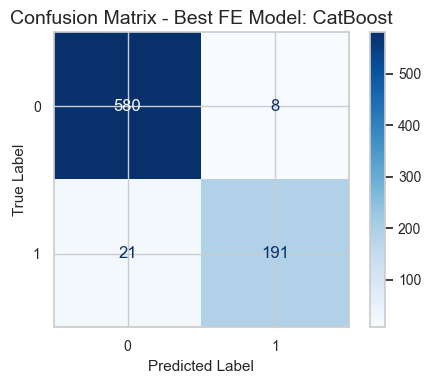

False Positives: 8
False Negatives: 21
Business note: False Negatives are high-risk because the model misses customers who actually churn.


In [31]:
best_fe_result = results_fe.sort_values(["ROC_AUC", "F1", "Recall"], ascending=False).iloc[0]
best_fe_model_name = best_fe_result["Model"]
best_fe_pipeline = trained_fe[best_fe_model_name]

y_pred_best_fe = best_fe_pipeline.predict(X_test_fe)

print(f"Best FE model: {best_fe_model_name}")
print("Classification report for best FE model:")
report_best_fe = pd.DataFrame(classification_report(y_test, y_pred_best_fe, output_dict=True, zero_division=0)).T
display(report_best_fe)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_fe, cmap="Blues", ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix - Best FE Model: {best_fe_model_name}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fe_best_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

cm = confusion_matrix(y_test, y_pred_best_fe)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print("Business note: False Negatives are high-risk because the model misses customers who actually churn.")


# 16. Feature Importance on Feature Engineered Data

Nếu best FE model có `feature_importances_`, phân tích top features trực tiếp. Nếu không, chọn một tree-based FE model available như CatBoost, XGBoost, LightGBM, RandomForest hoặc ExtraTrees để xem importance.

Mục tiêu là xem engineered features nào lọt top và original features nào vẫn giữ vai trò mạnh.


,feature,importance,feature_type
13,frequency_drop,23.0287,Engineered
7,Age,11.3656,Original
27,loyalty_score,7.6618,Engineered
14,frequency_ratio_current_total,6.5741,Engineered
17,engagement_score,5.8569,Engineered
18,total_engagement_score,3.4558,Engineered
42,log_lifetime,3.3437,Engineered
28,spending_per_month,3.2100,Engineered
10,Lifetime,3.1704,Original
43,log_additional_charges,2.9306,Engineered


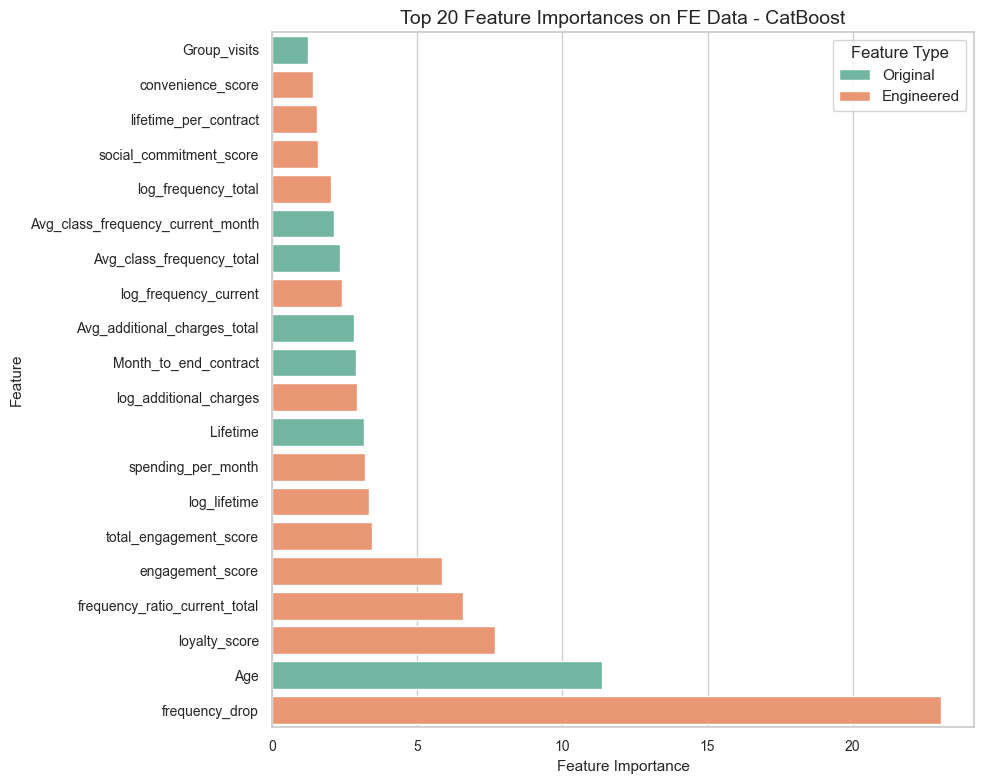

Top engineered features:


,feature,importance,feature_type
13,frequency_drop,23.0287,Engineered
27,loyalty_score,7.6618,Engineered
14,frequency_ratio_current_total,6.5741,Engineered
17,engagement_score,5.8569,Engineered
18,total_engagement_score,3.4558,Engineered
42,log_lifetime,3.3437,Engineered
28,spending_per_month,3.2100,Engineered
43,log_additional_charges,2.9306,Engineered
44,log_frequency_current,2.4061,Engineered
45,log_frequency_total,2.0280,Engineered


Top original features:


,feature,importance,feature_type
7,Age,11.3656,Original
10,Lifetime,3.1704,Original
9,Month_to_end_contract,2.8987,Original
8,Avg_additional_charges_total,2.8074,Original
11,Avg_class_frequency_total,2.3361,Original
12,Avg_class_frequency_current_month,2.1327,Original
6,Group_visits,1.2210,Original
5,Contract_period,1.0934,Original
0,gender,0.6111,Original
2,Partner,0.5025,Original


In [32]:
def get_feature_importance_from_pipeline(pipeline: Pipeline, feature_names: list[str]) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame()
    return pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

importance_pipeline = best_fe_pipeline
importance_model_name = best_fe_model_name
feature_importance_df = get_feature_importance_from_pipeline(importance_pipeline, X_train_fe.columns.tolist())

if feature_importance_df.empty:
    fallback_order = ["CatBoost", "XGBoost", "LightGBM", "Random Forest", "Extra Trees", "Gradient Boosting"]
    for candidate in fallback_order:
        if candidate in trained_fe:
            candidate_importance = get_feature_importance_from_pipeline(trained_fe[candidate], X_train_fe.columns.tolist())
            if not candidate_importance.empty:
                feature_importance_df = candidate_importance
                importance_model_name = candidate
                break

if feature_importance_df.empty:
    print("No feature_importances_ available from FE models.")
else:
    feature_importance_df["feature_type"] = np.where(feature_importance_df["feature"].isin(new_features), "Engineered", "Original")
    display(feature_importance_df.head(20))

    top20_importance = feature_importance_df.head(20).sort_values("importance", ascending=True)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top20_importance, x="importance", y="feature", hue="feature_type", dodge=False, palette="Set2")
    plt.title(f"Top 20 Feature Importances on FE Data - {importance_model_name}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.legend(title="Feature Type")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fe_top20_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    top_engineered = feature_importance_df[feature_importance_df["feature_type"] == "Engineered"].head(10)
    top_original = feature_importance_df[feature_importance_df["feature_type"] == "Original"].head(10)
    print("Top engineered features:")
    display(top_engineered)
    print("Top original features:")
    display(top_original)


# 17. Cross Validation on Best Candidates

Chạy StratifiedKFold 5-fold cho best original model và best FE model. Nếu feature engineering cải thiện test set nhưng không cải thiện cross validation, cần cẩn thận với overfitting. Nên ưu tiên model có mean metric tốt và std thấp.


Cross-validating Original - CatBoost...
Cross-validating Feature Engineered - CatBoost with fold-specific thresholds...


,experiment,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
0,Original,CatBoost,0.9487,0.0096,0.9255,0.0216,0.8775,0.0167,0.9008,0.0185,0.9858,0.0045
1,Feature Engineered,CatBoost,0.9565,0.0064,0.9380,0.0155,0.8954,0.0141,0.9161,0.0123,0.9900,0.0033


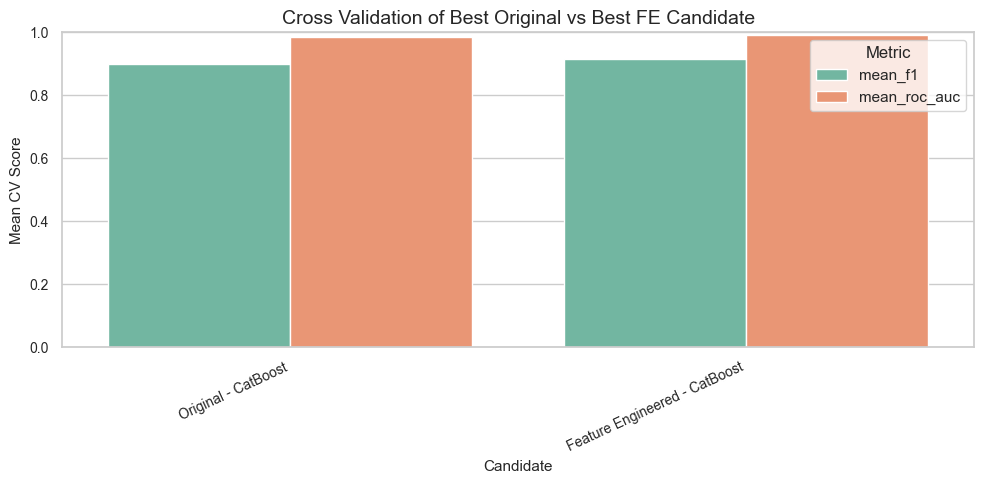

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


def calculate_feature_thresholds(X_train_fold: pd.DataFrame) -> dict:
    """Fit feature engineering thresholds on a training fold only."""
    if "Avg_additional_charges_total" not in X_train_fold.columns:
        return {"spending_q25": 0, "spending_q75": 0}
    return {
        "spending_q25": X_train_fold["Avg_additional_charges_total"].quantile(0.25),
        "spending_q75": X_train_fold["Avg_additional_charges_total"].quantile(0.75),
    }


def summarize_cv_scores(experiment: str, model_name: str, fold_scores: list[dict]) -> dict:
    scores_df = pd.DataFrame(fold_scores)
    return {
        "experiment": experiment,
        "model": model_name,
        "mean_accuracy": scores_df["accuracy"].mean(),
        "std_accuracy": scores_df["accuracy"].std(ddof=0),
        "mean_precision": scores_df["precision"].mean(),
        "std_precision": scores_df["precision"].std(ddof=0),
        "mean_recall": scores_df["recall"].mean(),
        "std_recall": scores_df["recall"].std(ddof=0),
        "mean_f1": scores_df["f1"].mean(),
        "std_f1": scores_df["f1"].std(ddof=0),
        "mean_roc_auc": scores_df["roc_auc"].mean(),
        "std_roc_auc": scores_df["roc_auc"].std(ddof=0),
    }


def cross_validate_original_candidate(model_name: str, model, X_data: pd.DataFrame, y_data: pd.Series) -> dict:
    pipeline = build_pipeline(model_name, clone(model), X_data.columns.tolist())
    cv_scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score=np.nan,
    )
    return {
        "experiment": "Original",
        "model": model_name,
        "mean_accuracy": np.nanmean(cv_scores["test_accuracy"]),
        "std_accuracy": np.nanstd(cv_scores["test_accuracy"]),
        "mean_precision": np.nanmean(cv_scores["test_precision"]),
        "std_precision": np.nanstd(cv_scores["test_precision"]),
        "mean_recall": np.nanmean(cv_scores["test_recall"]),
        "std_recall": np.nanstd(cv_scores["test_recall"]),
        "mean_f1": np.nanmean(cv_scores["test_f1"]),
        "std_f1": np.nanstd(cv_scores["test_f1"]),
        "mean_roc_auc": np.nanmean(cv_scores["test_roc_auc"]),
        "std_roc_auc": np.nanstd(cv_scores["test_roc_auc"]),
    }


def cross_validate_fe_candidate(model_name: str, model, X_data: pd.DataFrame, y_data: pd.Series) -> dict:
    """Cross-validate FE candidate while fitting FE thresholds inside each training fold."""
    fold_scores = []
    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx].copy()
        X_valid_fold = X_data.iloc[valid_idx].copy()
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        fold_thresholds = calculate_feature_thresholds(X_train_fold)
        X_train_fold_fe = create_features(X_train_fold, thresholds=fold_thresholds)
        X_valid_fold_fe = create_features(X_valid_fold, thresholds=fold_thresholds)

        pipeline = build_pipeline(model_name, clone(model), X_train_fold_fe.columns.tolist())
        pipeline.fit(X_train_fold_fe, y_train_fold)

        y_pred = pipeline.predict(X_valid_fold_fe)
        y_score = get_positive_scores(pipeline, X_valid_fold_fe)

        fold_scores.append({
            "accuracy": accuracy_score(y_valid_fold, y_pred),
            "precision": precision_score(y_valid_fold, y_pred, zero_division=0),
            "recall": recall_score(y_valid_fold, y_pred, zero_division=0),
            "f1": f1_score(y_valid_fold, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid_fold, y_score) if y_score is not None else np.nan,
        })
    return summarize_cv_scores("Feature Engineered", model_name, fold_scores)


best_original_name = results_original.sort_values(["ROC_AUC", "F1", "Recall"], ascending=False).iloc[0]["Model"]
best_fe_name = results_fe.sort_values(["ROC_AUC", "F1", "Recall"], ascending=False).iloc[0]["Model"]

cv_candidate_rows = []
if best_original_name in models:
    print(f"Cross-validating Original - {best_original_name}...")
    cv_candidate_rows.append(cross_validate_original_candidate(best_original_name, models[best_original_name], X_original, y))

if best_fe_name in models:
    print(f"Cross-validating Feature Engineered - {best_fe_name} with fold-specific thresholds...")
    cv_candidate_rows.append(cross_validate_fe_candidate(best_fe_name, models[best_fe_name], X_original, y))

cv_candidates_df = pd.DataFrame(cv_candidate_rows)
display(cv_candidates_df)

if not cv_candidates_df.empty:
    cv_plot = cv_candidates_df.melt(
        id_vars=["experiment", "model"],
        value_vars=["mean_f1", "mean_roc_auc"],
        var_name="metric",
        value_name="score",
    )
    cv_plot["candidate"] = cv_plot["experiment"] + " - " + cv_plot["model"]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=cv_plot, x="candidate", y="score", hue="metric", palette="Set2")
    plt.title("Cross Validation of Best Original vs Best FE Candidate")
    plt.xlabel("Candidate")
    plt.ylabel("Mean CV Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fe_cv_best_candidates.png", dpi=150, bbox_inches="tight")
    plt.show()


# 18. Save Results and Best Model

Lưu best model pipeline, bảng so sánh Original vs Feature Engineering và feature importance để sử dụng ở notebook tiếp theo.


In [34]:
best_model_path = MODELS_DIR / "best_feature_engineering_model.pkl"
comparison_path = REPORTS_DIR / "feature_engineering_comparison.csv"
importance_path = REPORTS_DIR / "feature_engineering_importance.csv"

best_model_artifact = {
    "pipeline": best_pipeline,
    "experiment": best_experiment,
    "model_name": best_model_name,
    "feature_thresholds": feature_thresholds if best_experiment == "Feature Engineered" else None,
    "original_features": original_features,
    "engineered_features": X_train_fe.columns.tolist() if best_experiment == "Feature Engineered" else None,
    "note": "If experiment is Feature Engineered, apply create_features(X, feature_thresholds) before pipeline.predict.",
}

joblib.dump(best_model_artifact, best_model_path)
comparison_df.to_csv(comparison_path, index=False)

if "feature_importance_df" in globals() and not feature_importance_df.empty:
    feature_importance_df.to_csv(importance_path, index=False)
else:
    pd.DataFrame(columns=["feature", "importance", "feature_type"]).to_csv(importance_path, index=False)

print(f"Saved best model artifact to: {best_model_path}")
print(f"Saved comparison results to: {comparison_path}")
print(f"Saved feature importance to: {importance_path}")


Saved best model artifact to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\models\best_feature_engineering_model.pkl
Saved comparison results to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\feature_engineering_comparison.csv
Saved feature importance to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\feature_engineering_importance.csv


# 19. Final Conclusions

Notebook này kiểm tra tác động của feature engineering so với dữ liệu gốc trong bài toán **Gym Customer Churn Prediction**.

Các kết luận cần rút ra sau khi chạy notebook:

- Feature engineering có cải thiện ROC-AUC, F1 hoặc Recall không.
- Model nào tốt nhất sau feature engineering.
- Engineered features nào lọt top feature importance.
- Original features nào vẫn giữ vai trò mạnh.
- Có dấu hiệu overfitting hay không khi so sánh test result với cross validation.
- Có nên giữ toàn bộ engineered features hay cần feature selection ở bước sau.

Ghi chú quan trọng:

- Nếu baseline đã rất cao, improvement nhỏ là hợp lý và không nên ép feature engineering quá mức.
- Không nên chỉ chạy theo accuracy. Với churn prediction, **Recall** và **F1 của class churn** thường quan trọng hơn vì false negative làm doanh nghiệp bỏ sót khách hàng có nguy cơ rời bỏ.
- Notebook này chưa dùng imbalance handling, chưa tuning hyperparameter và chưa dùng SHAP.

Hướng tiếp theo:

- Feature selection để loại feature nhiễu hoặc trùng lặp.
- Imbalance handling có kiểm soát, ví dụ class weights hoặc threshold tuning trước khi cân nhắc SMOTE.
- Hyperparameter tuning bằng RandomizedSearchCV hoặc Optuna.
- SHAP explainability để giải thích prediction ở cấp global và local.
- Chuẩn bị pipeline production với feature engineering transformer riêng để tránh leakage trong triển khai thực tế.
